# Boundary Conditions Correction for Constant-Thickness STW under Distributed Tip Load

This notebook documents the application of the correct Boundary Conditions (BCs) to the wingbox model of the Simple Transonic Wing (STW) wingbox with uniform thickness under a distributed tip load, and it demonstrates the Nastran linear buckling (SOL 105) and nonlinear (SOL 106) analyses with and without the use of CQUAD4 elements' offset.

***

Import shared utilities and define case-specific constants.

In [1]:
# Import system and OS modules to manage the Python path and file system interactions
import sys
import os

# When Jupyter's CWD is the notebook's own directory (stw-nastran-vs-cuf/),
# the project's `resources` package is not on sys.path.  Detect this and add
# the parent directory (notebooks/) automatically.
_parent = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(_parent, "resources")) and _parent not in sys.path:
    sys.path.insert(0, _parent)

# Import third-party libraries and functions
import numpy as np
from pyNastran.op2.op2 import read_op2
import openmdao.api as om

# Import custom utilities
from resources import pynastran_utils
from resources import plot_utils
from resources.STW import nastran_vs_cuf_utils
from resources.STW import stw_utils
from resources.STW import wingGeometry

# ── Case-specific constants ───────────────────────────────────────────────────
ANALYSIS_DIR = nastran_vs_cuf_utils.ANALYSIS_DIRECTORY_PATH
FIRST_SUBCASE_ID = nastran_vs_cuf_utils.FIRST_SUBCASE_ID
SECOND_SUBCASE_ID = nastran_vs_cuf_utils.SECOND_SUBCASE_ID
METHOD_SET_ID = nastran_vs_cuf_utils.METHOD_SET_ID
INPUT_NAME_SUFFIX = "const_thickness_dist_tip_load_correct_BCs"

# Applied load parameters
TOTAL_FORCE = 1.0  # reference unit load [N] – buckling load factor scales this
FORCE_RATIO = 0.25  # F(front spar) / F(rear spar)
FORCE_SET_ID = 1  # SID of the FORCE cards

# SOL 105 amplification factor for mode-shape visualisation
AMPLIFICATION_FACTOR = 2

Configure default plotting settings.

In [2]:
import matplotlib.pyplot as plt

nastran_vs_cuf_utils.configure_plotting()

COLORS = nastran_vs_cuf_utils.COLORS
MARKERS = nastran_vs_cuf_utils.MARKERS
GLASS_CEILING_COLOR = nastran_vs_cuf_utils.GLASS_CEILING_COLOR
TEXTWIDTH_INCHES = nastran_vs_cuf_utils.TEXTWIDTH_INCHES
FIG_HEIGHT_INCHES = nastran_vs_cuf_utils.FIG_HEIGHT_INCHES

## Review of STW Boundary Conditions

[The original BCs of the STW wingbox model](https://mdobenchmarks.github.io/MDOAeroelasticBenchmark/stw/model.html) are shown in the figure below. Symmetry BCs are applied at the outer nodes of the root rib, while displacements in $x$ and $z$ directions are constrained at the outer nodes of the Side Of Body (SOB) rib. The `pyLayout` module takes care of defining these BCs when generating the Nastran input file by means of SPC cards.

![STW Boundary Conditions](./figures/03_STW_BCs.png)

The original model of the STW did not include skin stringers, which were added for [this SciTech 2025 paper](https://doi.org/10.2514/6.2025-2811). The generation of the Nastran input file for the wingbox model with stringers is always performed by the `pyLayout` module. Since the stringers continue across the symmetry plane of the wing, the same symmetry BCs applied at the outer nodes of the root rib should be applied also to the nodes of the stringers at $y=0$ m.

However, it was discovered that the `pyLayout` model was propagating the BCs of each rib along the height of the rib at the chordwise locations corresponding to the skin stringers, as it can be observed in the figure below. The purple points represent the nodes associated to the SPC Nastran cards created by `pyLayout`. On top of the expected BCs, it is possible to observe columns of purple points in correspondence of the chordwise location of the skin stringers.

![Wrong STW Boundary Conditions](./figures/03_Wrong_BCs.png)

A fix was introduced in the `pyLayout` module to prevent the propagation of the BCs along the height of the rib at the chordwise locations of the skin stringers, and the correct BCs are shown in the figure below. The columns of purple points in correspondence of the chordwise location of the skin stringers have disappeared, and only the expected BCs are present.

![Correct STW Boundary Conditions](./figures/03_Correct_BCs.png)

At the same time, in order to maintain consistency with the CUF analyses performed in the previous notebooks, it was decided to remove the BCs at the nodes of the stringers at $y=0$ m, and keep only the BCs at the outer nodes of the root and SOB ribs. The final BCs are shown in the figure below.

![Final STW Boundary Conditions](./figures/03_Final_BCs.png)

## Definition of Linearly Distributed Tip Load

Create STW structural model with the same mesh as the SciTech 2025 paper.

In [3]:
target_length = 53e-3  # target element edge length [m]
stw_bdf, stw_layout = wingGeometry.create_base_bdf(target_length)
print(stw_bdf.get_bdf_stats())

pyGeo Initialization Type is: iges
Found 6 surfaces in Iges File.
Projecting Super Nodes...
Projecting All Nodes...
Setting up Ribs...
Setting up Spars...
Setting up Skins and Stringers...
Setting up Spar Bars
Setting up Rib Bars
Computing Topology and Numbering...
Unique Nodes: 45483
Total Nodes: 65046
Writing .bdf File...
---BDF Statistics---
SOL 103

bdf.spcs[1]: 192
  SPC:     192

bdf.params: 0
  PARAM    : 1

bdf.nodes: 45483
  GRID     : 45483

bdf.elements: 46432
  CQUAD4   : 46432

bdf.properties: 0
  PSHELL   : 1110

bdf.materials: 0
  MAT1     : 1




subcase=0 already exists...skipping


Apply a linearly distributed upward force at the wingbox tip. The total reference force is 1 N, split equally between the upper and lower skin nodes. The distribution is linear such that the nodal force on the front spar is 1/4 the nodal force on the rear spar (`FORCE_RATIO = 0.25`), inducing a twist down at the tip.

In [4]:
# Create deep copy of the base BDF for load application
distributed_tip_load_bdf = stw_bdf.__deepcopy__({})

# Apply linearly distributed tip load
stw_utils.apply_distributed_tip_load(
    layout=stw_layout,
    bdf=distributed_tip_load_bdf,
    ratio=FORCE_RATIO,
    total_force=TOTAL_FORCE,
    set_id=FORCE_SET_ID,
)

# Create the static-load subcase
pynastran_utils.create_static_load_subcase(
    bdf=distributed_tip_load_bdf,
    load_set_id=FORCE_SET_ID,
    subcase_id=FIRST_SUBCASE_ID,
)

## CQUAD4 Elements without Offset

### Linear Buckling Analysis (SOL 105)

#### Set Up

In [5]:
# Define key and label case with no CQUAD4 offset
nastran_key = "No CQUAD4 offset"

# Initialize data structures for storing linear buckling results
analysis_keys = [nastran_key]  # will store analysis keys - used for indexing results and for legend labels
linear_buckling_loads = {}  # will store {key: linear buckling load} for each analysis case

# Create deep copy of the load BDF for SOL 105
sol_105_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output
sol_105_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

subcase=1 already exists...skipping


#### Run

In [6]:
# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name="sol_105_distributed_tip_load")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_const_thickness_dist_tip_load_correct_BCs.bdf completed
Wall time: 37.0 s


#### Results

Read the op2 file, print the linear buckling load, and plot the critical buckling mode shape.

Linear buckling load: 133275.28 N


/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/ipympl/backend_nbagg.py:336: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  self.figure.savefig(buf, format='png', dpi='figure')


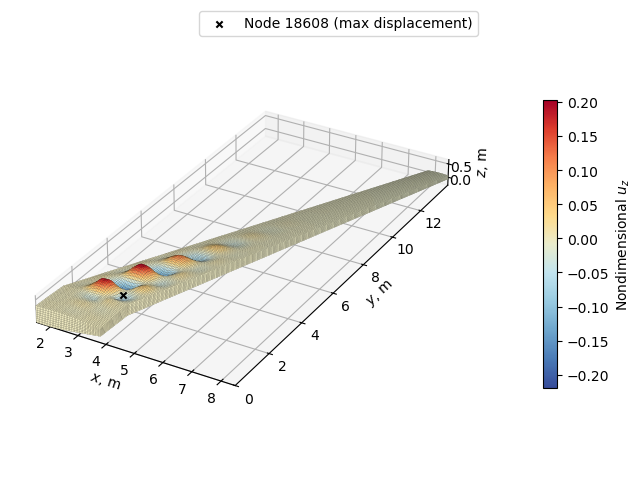


Max-displacement node ID : 18608
Node coordinates [x, y, z] (m): [3.02882401 2.48676316 0.27278431]


In [7]:
%matplotlib widget

# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIR, f"sol_105_{INPUT_NAME_SUFFIX}.op2")
sol_105_op2 = read_op2(op2_filepath, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_loads[nastran_key] = sol_105_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_loads[nastran_key]:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {max_disp_node_id}")
print(f"Node coordinates [x, y, z] (m): {sol_105_op2.nodes[max_disp_node_id].xyz}")

Critical buckling mode is a global buckling of the first few top skin panels after the SOB break, with two half-waves along the chord, which involve also the deformation of the stringers.

### Nonlinear Analyses (SOL 106)

Several arc-length analyses are run, each using different NLPARM convergence settings. All analyses are executed with an applied load of 1.5 times the linear buckling load, which is expected to induce evident buckling deformation.

In [8]:
# Initialize data structures for storing SOL 106 results
sol_106_op2s = {}  # will store {key: OP2 object}

# Define the applied load for the SOL 106 cases as 150% of the linear buckling load
applied_load = linear_buckling_loads[nastran_key] * 1.5

#### No Offset

This is the case with the tightest convergence settings, taken from those used in the SciTech 2025 paper. The table below summarizes the parameters of the NLPARM and NLPCI cards for this case.

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $10^{-5}$ |
| EPSP | $10^{-5}$ |
| DESITER | 4 |
| MXINC | 500 |

In [9]:
# Define NLPARM and NLPCI parameters
conv = "PU"
epsp = 1e-5
epsu = 1e-5
mxinc = 500

##### Set Up and Run

In [10]:
# Build the SOL 106 BDF using the shared helper
sol_106_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,  # scale factor applied to the reference unit load
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

# Create OpenMDAO nonlinear problem
nonlinear_problem = om.Problem(name=f"sol_106_distributed_tip_load")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=INPUT_NAME_SUFFIX,
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_filepath, load_geometry=True, debug=None)

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_const_thickness_dist_tip_load_correct_BCs.bdf completed
Wall time: 89366.0 s


## CQUAD4 Elements with Offset

### Linear Buckling Analysis (SOL 105)

#### Set Up

Before applying the offset to the CQUAD4 elements, we visualize the orientation of the elements' normal vectors to make sure that the offset is applied in the correct direction.

In [11]:
# Define key for the case with CQUAD4 offset
nastran_key = "CQUAD4 offset"
analysis_keys.append(nastran_key)

# Create deep copy of the load BDF for SOL 105
sol_105_offset_bdf = distributed_tip_load_bdf.__deepcopy__({})

# Set up linear buckling solution with eigenvalue method set
pynastran_utils.set_up_sol_105(
    bdf=sol_105_offset_bdf,
    static_load_set_id=FORCE_SET_ID,
    method_set_id=METHOD_SET_ID,
)

# Request element stress output
sol_105_offset_bdf.case_control_deck.subcases[FIRST_SUBCASE_ID].add_result_type(
    "STRESS", "ALL", ["PLOT"]
)

# Find element ids for the specified parts
element_ids_dict = stw_utils.find_element_ids(
    stw_layout, ["U_SKIN", "L_SKIN", "SPAR.00", "SPAR.10"]
)

subcase=1 already exists...skipping


We observe that the normal vectors of the CQUAD4 elements of the skins and the spars are all oriented towards the outside of the wing, except for the front spar elements. This means that we need to use a positive offset value for the skin and rear spar elements, while we need to use a negative offset value for the front spar elements.

In [12]:
# Add offset to top skin CQUAD4 elements
for eid in element_ids_dict["U_SKIN"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to bottom skin CQUAD4 elements
for eid in element_ids_dict["L_SKIN"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to front spar CQUAD4 elements
for eid in element_ids_dict["SPAR.00"]:
    # Minus sign is needed to offset in the correct direction since the front spar normals point inwards (towards the rear spar)
    sol_105_offset_bdf.elements[eid].zoffset = -wingGeometry.panelThickness / 2

# Add offset to rear spar CQUAD4 elements
for eid in element_ids_dict["SPAR.10"]:
    sol_105_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

#### Run

In [13]:
# Define suffix for this analysis variant
analysis_suffix = "cquad4_offset"

# Define OpenMDAO linear buckling problem
linear_problem = om.Problem(name=f"sol_105_{analysis_suffix}")
linear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{analysis_suffix}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_105_offset_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
linear_problem.setup()
linear_problem.run_model()

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_105_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_105.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_105_const_thickness_dist_tip_load_correct_BCs_cquad4_offset.bdf completed
Wall time: 37.0 s


#### Results

Linear buckling load: 139301.12 N


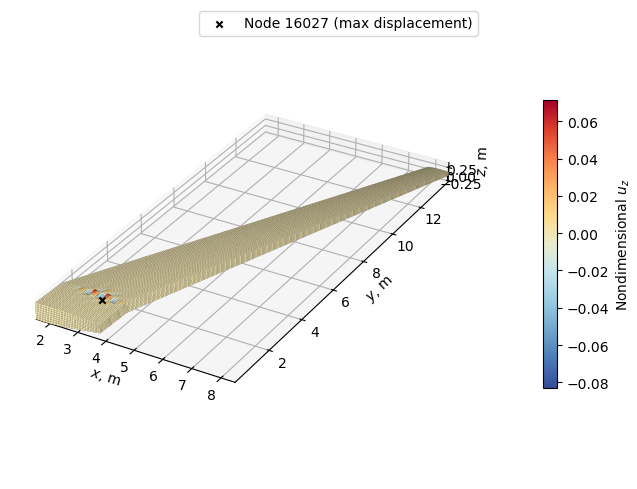


Max-displacement node ID : 16027
Node coordinates [x, y, z] (m): [3.00044643 1.3501     0.29041465]


In [14]:
# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIR, f"sol_105_{INPUT_NAME_SUFFIX}_{analysis_suffix}.op2")
sol_105_offset_op2 = read_op2(op2_filepath, load_geometry=True, debug=None)

# Extract and print linear buckling load
# Note that the eigenvalues of SOL 105 are buckling load factors, that is to say
# P_buckling/P_applied. Since we applied a reference load of 1 N, the buckling load
# factor is numerically equal to the buckling load in Newtons.
linear_buckling_loads[nastran_key] = sol_105_offset_op2.eigenvectors[SECOND_SUBCASE_ID].eigr
print(f"Linear buckling load: {linear_buckling_loads[nastran_key]:.2f} N")

# Plot critical buckling mode shape
_, ax, _ = plot_utils.plot_eigenvector(
    op2=sol_105_offset_op2,
    subcase_id=SECOND_SUBCASE_ID,
    displacement_component="tz",
    colormap="sunset",
    displacement_amplification_factor=AMPLIFICATION_FACTOR,
    shrink_colorbar=0.6,
    colorbar_pad=0.09,
)

# Mark and record the node with maximum out-of-plane displacement
offset_model_max_disp_node_id = plot_utils.plot_max_displacement_node(
    axes=ax, op2=sol_105_offset_op2, displacement_amplification_factor=AMPLIFICATION_FACTOR
)

# Add plot legend, adjust 3D plot settings, and display
ax.legend()
nastran_vs_cuf_utils.adjust_3d_plot(ax)
plt.show()

# Print the ID and coordinates of the node with maximum out-of-plane displacement
print(f"\nMax-displacement node ID : {offset_model_max_disp_node_id}")
print(
    f"Node coordinates [x, y, z] (m): {sol_105_offset_op2.nodes[offset_model_max_disp_node_id].xyz}"
)

As expected, the linear buckling load increases with respect to the previous Nastran analysis without offset, since the wingbox is effectively stiffer with the offset. The stiffening of the model is also reflected in the critical buckling mode shape, which now is confined within the rib-stringer bays just before the SOB break.

### Nonlinear Analysis (SOL 106)

#### Set Up and Run

We use the solver settings summarized in the table below, (same as in the analysis with EPSP = EPSU = 1e-5 without offset).

| Parameter | Value |
|--------|--------|
| KMETHOD | ITER |
| KSTEP | -1 |
| MAXITER | 3 |
| CONV | PU |
| EPSU | $10^{-5}$ |
| EPSP | $10^{-5}$ |
| DESITER | 4 |
| MXINC | 500 |

In [15]:
# Define the applied load for the SOL 106 cases as 150% of the linear buckling load
applied_load = linear_buckling_loads[nastran_key] * 1.5

# Build the SOL 106 BDF using the shared helper
sol_106_offset_bdf = nastran_vs_cuf_utils.setup_sol_106_bdf(
    base_bdf=distributed_tip_load_bdf,
    load_scale_factor=applied_load,  # scale factor applied to the reference unit load
    force_set_id=FORCE_SET_ID,
    analysis_directory_path=ANALYSIS_DIR,
    conv=conv,
    eps_p=epsp,
    eps_u=epsu,
    mxinc=mxinc,
)

# Add offset to top skin CQUAD4 elements
for eid in element_ids_dict["U_SKIN"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to bottom skin CQUAD4 elements
for eid in element_ids_dict["L_SKIN"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Add offset to front spar CQUAD4 elements
for eid in element_ids_dict["SPAR.00"]:
    sol_106_offset_bdf.elements[eid].zoffset = -wingGeometry.panelThickness / 2

# Add offset to rear spar CQUAD4 elements
for eid in element_ids_dict["SPAR.10"]:
    sol_106_offset_bdf.elements[eid].zoffset = wingGeometry.panelThickness / 2

# Create OpenMDAO nonlinear problem
nonlinear_problem = om.Problem(name=f"sol_106_{analysis_suffix}")
nonlinear_problem.model = stw_utils.NastranAnalysis(
    layout=stw_layout,
    input_name_suffix=f"{INPUT_NAME_SUFFIX}_{analysis_suffix}",
    analysis_directory_path=ANALYSIS_DIR,
    bdf=sol_106_offset_bdf,
    run_flag=False,  # analysis already computed; set True to re-run
)
nonlinear_problem.setup()
nonlinear_problem.run_model()

# Read op2 file
op2_filepath = os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{analysis_suffix}.op2")
sol_106_op2s[nastran_key] = read_op2(op2_filepath, load_geometry=True, debug=None)

/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/component.py:203: DistributedComponentWarning:'sol_106_mesh' <class NastranMesh>: Component contains distributed variables, but there is no distributed vector implementation (MPI/PETSc) available. The default non-distributed vectors will be used.
/home/fmamitrotta/anaconda3/envs/aeroelastic-opt-benchmark/lib/python3.10/site-packages/openmdao/core/group.py:2885: UnitsWarning:<model> <class NastranAnalysis>: Output 'ivc.yield_strength' with units of 'Pa' is connected to input 'sol_106.struct_post.struct_function.yield_strength' which has no units.


Nastran job sol_106_const_thickness_dist_tip_load_correct_BCs_cquad4_offset.bdf completed
Wall time: 97465.0 s


#### Comparison between No Offset and Offset Analyses

Extract load and displacements.

In [16]:
# Find tip nodes (used to compute mean tip deflection)
tip_nodes_ids, _ = stw_utils.find_tip_nodes(stw_layout, sol_106_op2s[nastran_key])

# Initialize data structures for storing load-displacement history
load = {}
tip_disp = {}
u_z = {}
u_y = {}

# Iterate through analyses, extract load and displacements
for nastran_key in analysis_keys:
    _, loads, disps = pynastran_utils.read_load_displacement_history_from_op2(
        op2=sol_106_op2s[nastran_key], node_ids=list(tip_nodes_ids) + [max_disp_node_id, offset_model_max_disp_node_id]
    )
    load[nastran_key] = loads[FIRST_SUBCASE_ID][:, 2]
    tip_disp[nastran_key] = stw_utils.calculate_tip_deflection(
        disps[tip_nodes_ids[0]][FIRST_SUBCASE_ID],
        disps[tip_nodes_ids[1]][FIRST_SUBCASE_ID],
    )
    u_z[nastran_key] = {
        max_disp_node_id: disps[max_disp_node_id][FIRST_SUBCASE_ID][:, 2],
        offset_model_max_disp_node_id: disps[offset_model_max_disp_node_id][FIRST_SUBCASE_ID][:, 2],
    }
    u_y[nastran_key] = {
        max_disp_node_id: disps[max_disp_node_id][FIRST_SUBCASE_ID][:, 1],
        offset_model_max_disp_node_id: disps[offset_model_max_disp_node_id][FIRST_SUBCASE_ID][:, 1],
    }

# Save equilibrium path to CSV with displacements at both local nodes
nastran_vs_cuf_utils.save_equilibrium_path_csv(
    filepath=os.path.join(ANALYSIS_DIR, f"sol_106_{INPUT_NAME_SUFFIX}_{analysis_suffix}.csv"),
    columns={
        "total_applied_load_N": load[nastran_key],
        "tip_displacement_m": tip_disp[nastran_key],
        f"u_z_node{max_disp_node_id}_m": u_z[nastran_key][max_disp_node_id],
        f"u_y_node{max_disp_node_id}_m": u_y[nastran_key][max_disp_node_id],
        f"u_z_node{offset_model_max_disp_node_id}_m": u_z[nastran_key][offset_model_max_disp_node_id],
        f"u_y_node{offset_model_max_disp_node_id}_m": u_y[nastran_key][offset_model_max_disp_node_id],
    },
    local_nodes={
        max_disp_node_id: sol_106_op2s[nastran_key].nodes[max_disp_node_id].xyz,
        offset_model_max_disp_node_id: sol_106_op2s[nastran_key].nodes[offset_model_max_disp_node_id].xyz,
    },
)

Plot the tip displacement equilibrium paths for both Nastran models.

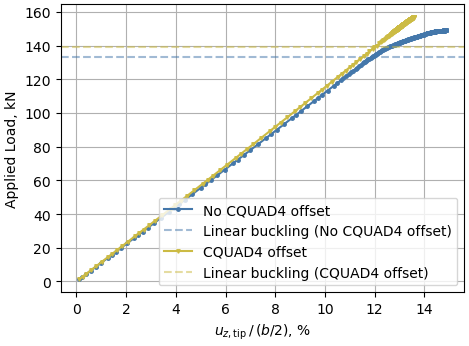

In [17]:
# Create figure
fig, ax = plt.subplots(figsize=(TEXTWIDTH_INCHES *.75, FIG_HEIGHT_INCHES))

# Iterate through analyses
for i, key in enumerate(analysis_keys):
    # Plot load-displacement history
    ax.plot(
        tip_disp[key] / wingGeometry.semiSpan * 100,
        load[key] / 1e3,
        marker=MARKERS[i],
        color=COLORS[i],
        label=key,
    )
    # Plot linear buckling load as horizontal dashed line
    ax.axhline(
        y=linear_buckling_loads[key] / 1e3,
        linestyle="--",
        color=COLORS[i],
        alpha=0.5,
        label=f"Linear buckling ({key})",
    )

# Add plot labels, legend, grid, and display
ax.set_xlabel(r"$u_{z,\mathrm{tip}}\,/\,(b/2)$, %")
ax.set_ylabel("Applied Load, kN")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

Plot the local displacement equilibrium paths at the two monitoring nodes (maximum out-of-plane displacement nodes from the no-offset and offset SOL 105 models).

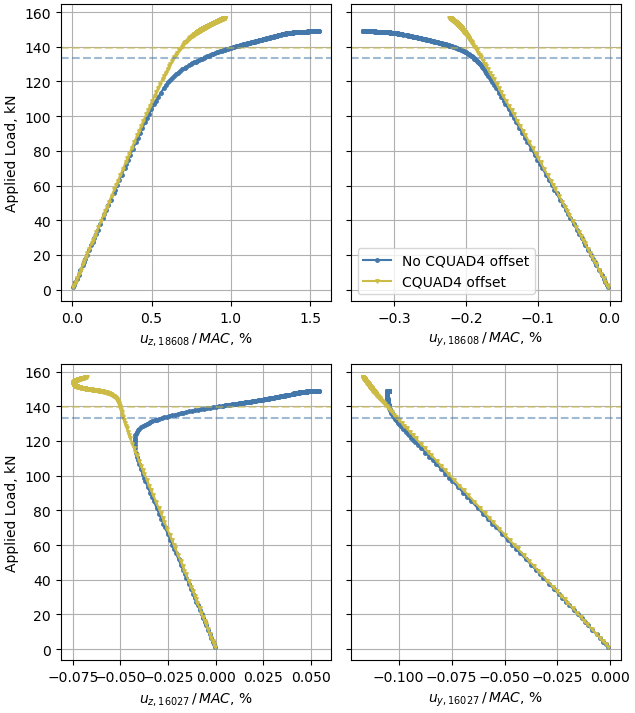

In [18]:
# Define node IDs for which to plot load-displacement curves of local displacements
node_ids = [max_disp_node_id, offset_model_max_disp_node_id]

# Create figure with 2 rows (one per node) and 2 columns (u_z and u_y)
fig, axes = plt.subplots(
    2, 2, sharey=True, figsize=(TEXTWIDTH_INCHES, FIG_HEIGHT_INCHES * 2)
)

# Iterate through nodes and analyses
for row, nid in enumerate(node_ids):
    for i, key in enumerate(analysis_keys):
        # u_z column
        axes[row, 0].plot(
            u_z[key][nid] / wingGeometry.meanAerodynamicChord * 100,
            load[key] / 1e3,
            marker=MARKERS[i],
            color=COLORS[i],
            label=key if row == 0 else None,
        )
        # u_y column
        axes[row, 1].plot(
            u_y[key][nid] / wingGeometry.meanAerodynamicChord * 100,
            load[key] / 1e3,
            marker=MARKERS[i],
            color=COLORS[i],
            label=key if row == 0 else None,
        )

    # Add linear buckling reference lines
    for j, key in enumerate(analysis_keys):
        for ax in axes[row, :]:
            ax.axhline(
                y=linear_buckling_loads[key] / 1e3,
                linestyle="--",
                color=COLORS[j],
                alpha=0.5,
            )
            ax.grid(True)

    # Set x-axis labels
    axes[row, 0].set_xlabel(f"$u_{{z,{nid}}}\\,/\\,MAC$, %")
    axes[row, 1].set_xlabel(f"$u_{{y,{nid}}}\\,/\\,MAC$, %")
    axes[row, 0].set_ylabel("Applied Load, kN")

# Add legends to the first row of subplots only
axes[0, 1].legend()
plt.tight_layout()
plt.show()